In [15]:
#import Libraries for Part1
import numpy as np
import matplotlib.pyplot as plt
from sklearn.kernel_ridge import KernelRidge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

#import Libraries for Part2
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_curve, auc



In [16]:
# A) Normal Ridge Regression using 5 different values of 𝜆, including 𝜆 = 0.

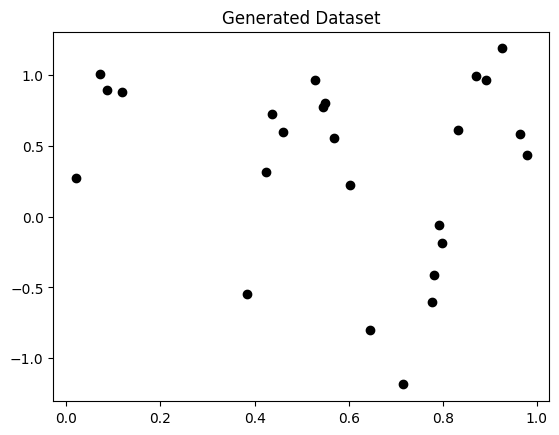

In [17]:
# ----- Generate dataset -----
np.random.seed(0)

N = 25
x = np.random.rand(N)              # x_i ∈ [0, 1]
noise = np.random.uniform(-0.3, 0.3, N)
y = np.sin(5 * np.pi * x) + noise  # y_i = sin(5πx) + noise

# Points for plotting smooth curves
x_plot = np.linspace(0, 1, 300)
y_true = np.sin(5 * np.pi * x_plot)

plt.scatter(x, y, color="black")
plt.title("Generated Dataset")
plt.show()

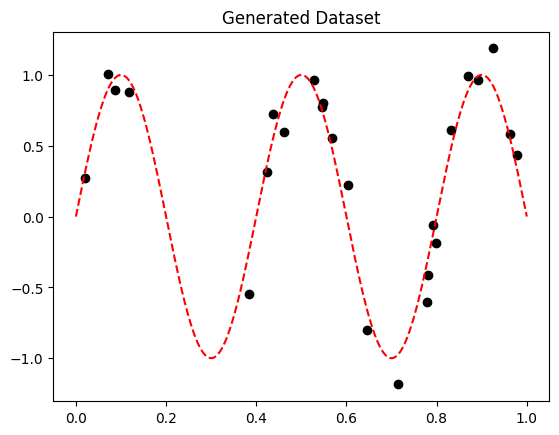

In [18]:
# ----- Generate dataset -----
np.random.seed(0)

N = 25
x = np.random.rand(N)              # x_i ∈ [0, 1]
noise = np.random.uniform(-0.3, 0.3, N)
y = np.sin(5 * np.pi * x) + noise  # y_i = sin(5πx) + noise

# Points for plotting smooth curves
x_plot = np.linspace(0, 1, 300)
y_true = np.sin(5 * np.pi * x_plot)

plt.scatter(x, y, color="black")
plt.plot(x_plot, y_true, 'r--')
plt.title("Generated Dataset")
plt.show()

In [19]:
np.random.seed(0)
N = 25

# Random x in [0, 1]
x = np.random.rand(N)

# Noise in [-0.3, 0.3]
noise = np.random.uniform(-0.3, 0.3, N)

# y = sin(5πx) + noise
y = np.sin(5 * np.pi * x) + noise


In [20]:
degree = 9
poly = PolynomialFeatures(degree=degree)

# Create polynomial features
X = poly.fit_transform(x.reshape(-1, 1))


In [21]:
x_plot = np.linspace(0, 1, 300)
X_plot = poly.transform(x_plot.reshape(-1, 1))

# True underlying function
y_true = np.sin(5 * np.pi * x_plot)


MSE for lambda 0: 0.012883523096999487
MSE for lambda 0.001: 0.26952201590504
MSE for lambda 0.01: 0.30277473526527876
MSE for lambda 0.1: 0.3161608557643212
MSE for lambda 1: 0.3446303050989604


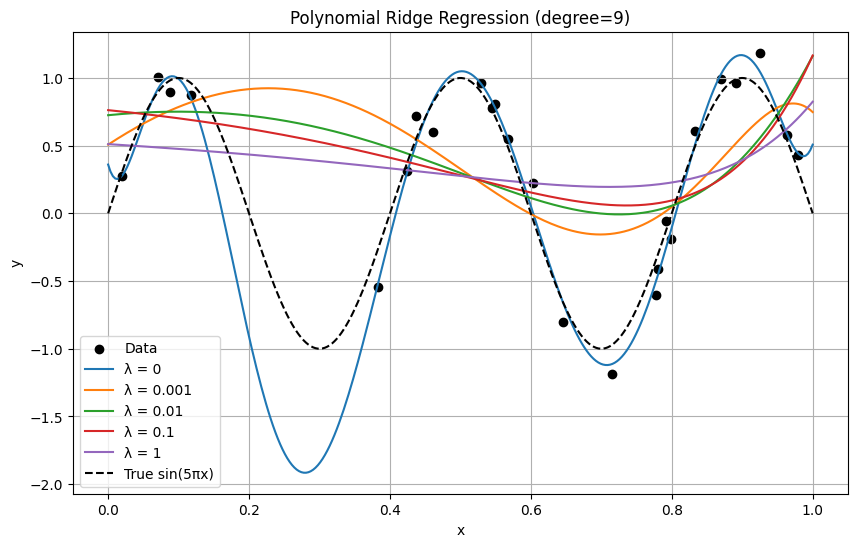

In [22]:
lambdas = [0, 0.001, 0.01, 0.1, 1]

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color="black", label="Data")

for lam in lambdas:
    model = Ridge(alpha=lam, fit_intercept=False)
    model.fit(X, y)

    # Predictions for plot
    y_pred = model.predict(X_plot)
    plt.plot(x_plot, y_pred, label=f"λ = {lam}")

    # Predictions on training points (for MSE)
    y_train_pred = model.predict(X)
    mse = mean_squared_error(y, y_train_pred)
    print(f"MSE for lambda {lam}: {mse}")

# True function
plt.plot(x_plot, y_true, "k--", label="True sin(5πx)")

plt.title(f"Polynomial Ridge Regression (degree={degree})")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


In [23]:
# B) RBF Kernel Ridge Regression using 5 different values of 𝜆, including 𝜆 = 0.

In [24]:
# Sort x so plots look smooth
sorted_idx = np.argsort(x)
x = x[sorted_idx]
y = y[sorted_idx]

In [25]:
"""Compute RBF value exp(-(x - alpa)^2 / lam)."""
def rbf(x, alpha, lam):
    return np.exp(-(x - alpha)**2 / lam)

def rbf_design_matrix(x, alpha, sigma):
    return np.array([[rbf(xi, cj, sigma) for cj in alpha] for xi in x])


In [26]:
def train_rbf_model(x, y, M):
    """
    Train an RBF regression model with M basis functions.
    No regularization (pure least squares).
    """
    # Evenly spaced centers in [0, 1]
    alpha = np.linspace(0, 1, M)

    # Reasonable width (sigma)
    sigma = 1 / M

    # Build design matrix Φ
    Phi = rbf_design_matrix(x, alpha, sigma)

    # Compute weights using pseudoinverse (least squares)
    w = np.linalg.pinv(Phi) @ y

    return alpha, sigma, w


In [27]:
def predict_rbf(x_new, alpha, sigma, w):
    """Predict y for new x points."""
    Phi_new = rbf_design_matrix(x_new, alpha, sigma)
    return Phi_new @ w


R² score for M=1: 0.0189
R² score for M=5: 0.3121
R² score for M=10: 0.9699
R² score for M=50: 1.0000


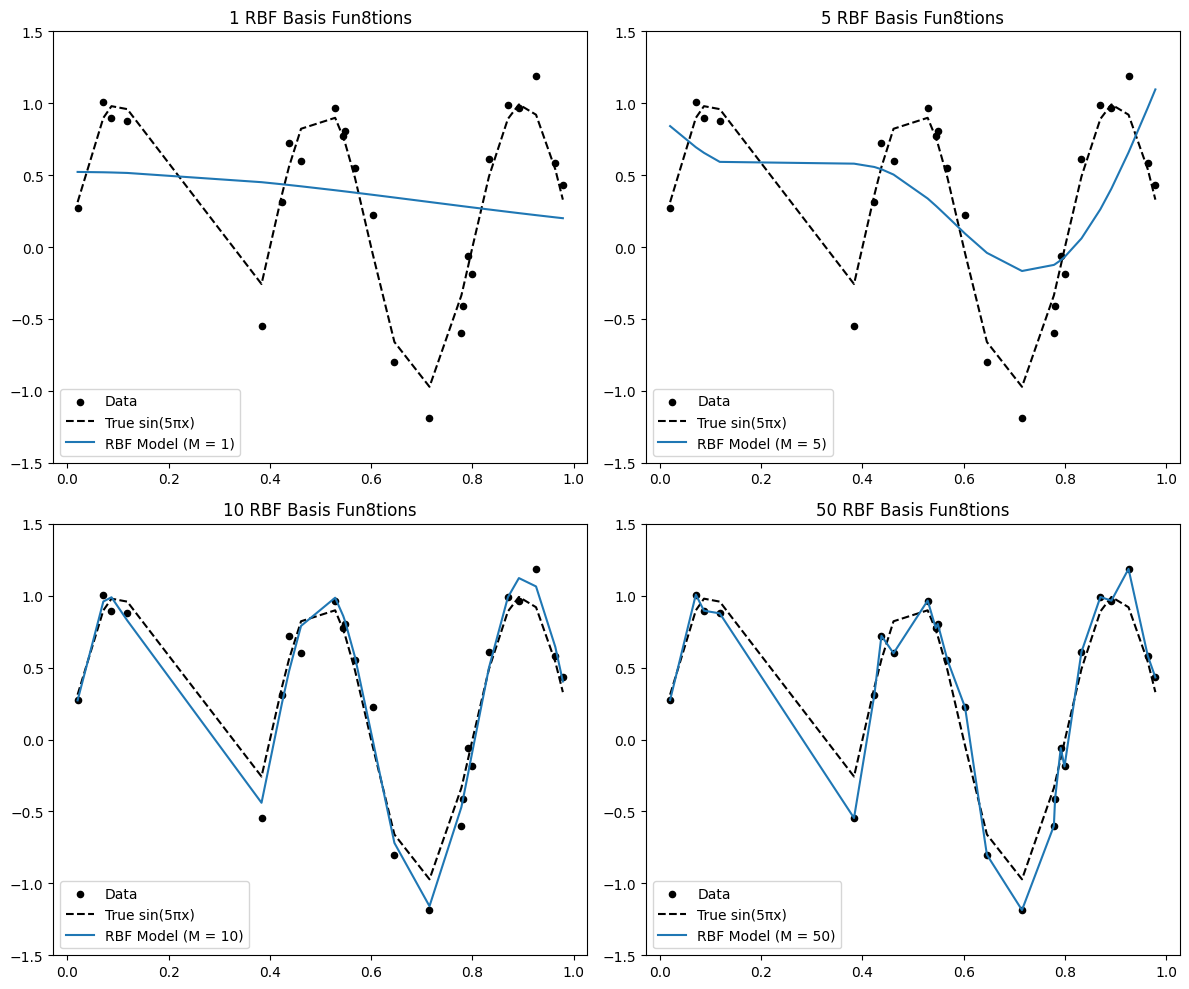

In [28]:
# Values of M (number of RBF functions)
M_values = [1, 5, 10, 50]

# True function
y_true = np.sin(5 * np.pi * x)

plt.figure(figsize=(12, 10))

for i, M in enumerate(M_values, 1):
    # Train model
    centers, sigma, w = train_rbf_model(x, y, M)

    # Predict on the same x points
    y_pred = predict_rbf(x, centers, sigma, w)

    # Compute R² score
    r2 = r2_score(y, y_pred)
    print(f"R² score for M={M}: {r2:.4f}")

    # Plot
    plt.subplot(2, 2, i)
    plt.scatter(x, y, s=20, color="black", label="Data")
    plt.plot(x, y_true, "k--", label="True sin(5πx)")
    plt.plot(x, y_pred, label=f"RBF Model (M = {M})")

    plt.title(f"{M} RBF Basis Fun8tions")
    plt.ylim(-1.5, 1.5)
    plt.legend()

plt.tight_layout()
plt.show()


In [29]:
#part 2:Logistic Regression

In [30]:
# Data Preprocessing Part
def data_processing(df):
    df = df.copy()

    # 1) HANDLE MISSING DATA
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    medians = df[numeric_cols].median()
    df[numeric_cols] = df[numeric_cols].fillna(medians)
    # 2) OUTLIER CAPPING
    outlier_cols = ['Age', 'Income', 'Tenure', 'SupportCalls']
    outlier_cols = [c for c in outlier_cols if c in df.columns] 
    for col in outlier_cols:
        lower = df[col].quantile(0.01)
        upper = df[col].quantile(0.98)
        df[col] = df[col].clip(lower=lower, upper=upper)
    # 3) FEATURE SCALING
    scaler = MinMaxScaler()
    df[outlier_cols] = scaler.fit_transform(df[outlier_cols])
    return df
#read the data and preprocessing
df = pd.read_csv("customer_data.csv")
#remove customer id because its not nessery for learning
df = df.drop("CustomerID",axis=1)
#apply preproccing from assignment1
df_processed = data_processing(df)

In [31]:
#split the data 2500 train , 500 val , 500 test
train_df, temp_df = train_test_split(df_processed, train_size=2500, shuffle=True, random_state=42)
val_df, test_df = train_test_split(temp_df, train_size=500, shuffle=True, random_state=42)
#split to X:Data Matrex and y:target vector 
X_train = train_df.drop("ChurnStatus", axis=1)
y_train = train_df["ChurnStatus"]
X_val = val_df.drop("ChurnStatus", axis=1)
y_val = val_df["ChurnStatus"]
X_test = test_df.drop("ChurnStatus", axis=1)
y_test = test_df["ChurnStatus"]

In [32]:
#LINEAR LOGISTIC REGRESSION
model_linear = LogisticRegression(max_iter=5000)
model_linear.fit(X_train, y_train)

#Predict
y_train_pred_lin = model_linear.predict(X_train)
y_val_pred_lin   = model_linear.predict(X_val)
y_test_pred_lin  = model_linear.predict(X_test)

#Metrics
train_acc_lin = accuracy_score(y_train, y_train_pred_lin)
val_acc_lin   = accuracy_score(y_val, y_val_pred_lin)
test_acc_lin  = accuracy_score(y_test, y_test_pred_lin)

train_prec_lin = precision_score(y_train, y_train_pred_lin)
val_prec_lin   = precision_score(y_val, y_val_pred_lin)
test_prec_lin  = precision_score(y_test, y_test_pred_lin)

train_rec_lin = recall_score(y_train, y_train_pred_lin)
val_rec_lin   = recall_score(y_val, y_val_pred_lin)
test_rec_lin  = recall_score(y_test, y_test_pred_lin)

In [33]:
#POLYNOMIAL DEGREE 2 
poly2 = PolynomialFeatures(degree=2)

X_train_poly2 = poly2.fit_transform(X_train)
X_val_poly2   = poly2.transform(X_val)
X_test_poly2  = poly2.transform(X_test)

model_poly2 = LogisticRegression(max_iter=5000)
model_poly2.fit(X_train_poly2, y_train)

y_train_pred_poly2 = model_poly2.predict(X_train_poly2)
y_val_pred_poly2   = model_poly2.predict(X_val_poly2)
y_test_pred_poly2  = model_poly2.predict(X_test_poly2)

train_acc2 = accuracy_score(y_train, y_train_pred_poly2)
val_acc2   = accuracy_score(y_val, y_val_pred_poly2)
test_acc2  = accuracy_score(y_test, y_test_pred_poly2)

train_prec2 = precision_score(y_train, y_train_pred_poly2)
val_prec2   = precision_score(y_val, y_val_pred_poly2)
test_prec2  = precision_score(y_test, y_test_pred_poly2)

train_rec2 = recall_score(y_train, y_train_pred_poly2)
val_rec2   = recall_score(y_val, y_val_pred_poly2)
test_rec2  = recall_score(y_test, y_test_pred_poly2)

In [34]:
#POLYNOMIAL DEGREE 5
poly5 = PolynomialFeatures(degree=5)

X_train_poly5 = poly5.fit_transform(X_train)
X_val_poly5   = poly5.transform(X_val)
X_test_poly5  = poly5.transform(X_test)

model_poly5 = LogisticRegression(max_iter=5000)
model_poly5.fit(X_train_poly5, y_train)

y_train_pred_poly5 = model_poly5.predict(X_train_poly5)
y_val_pred_poly5   = model_poly5.predict(X_val_poly5)
y_test_pred_poly5  = model_poly5.predict(X_test_poly5)

train_acc5 = accuracy_score(y_train, y_train_pred_poly5)
val_acc5   = accuracy_score(y_val, y_val_pred_poly5)
test_acc5  = accuracy_score(y_test, y_test_pred_poly5)

train_prec5 = precision_score(y_train, y_train_pred_poly5)
val_prec5   = precision_score(y_val, y_val_pred_poly5)
test_prec5  = precision_score(y_test, y_test_pred_poly5)

train_rec5 = recall_score(y_train, y_train_pred_poly5)
val_rec5   = recall_score(y_val, y_val_pred_poly5)
test_rec5  = recall_score(y_test, y_test_pred_poly5)

In [35]:
#POLYNOMIAL DEGREE 9
poly9 = PolynomialFeatures(degree=9)

X_train_poly9 = poly9.fit_transform(X_train)
X_val_poly9   = poly9.transform(X_val)
X_test_poly9  = poly9.transform(X_test)

model_poly9 = LogisticRegression(max_iter=5000)
model_poly9.fit(X_train_poly9, y_train)

y_train_pred_poly9 = model_poly9.predict(X_train_poly9)
y_val_pred_poly9   = model_poly9.predict(X_val_poly9)
y_test_pred_poly9  = model_poly9.predict(X_test_poly9)

train_acc9 = accuracy_score(y_train, y_train_pred_poly9)
val_acc9   = accuracy_score(y_val, y_val_pred_poly9)
test_acc9  = accuracy_score(y_test, y_test_pred_poly9)

train_prec9 = precision_score(y_train, y_train_pred_poly9)
val_prec9   = precision_score(y_val, y_val_pred_poly9)
test_prec9  = precision_score(y_test, y_test_pred_poly9)

train_rec9 = recall_score(y_train, y_train_pred_poly9)
val_rec9   = recall_score(y_val, y_val_pred_poly9)
test_rec9  = recall_score(y_test, y_test_pred_poly9)

          train_acc  val_acc  test_acc  train_prec  val_prec  test_prec  \
Linear       0.9724    0.980     0.978      1.0000    1.0000     1.0000   
Degree 2     0.9768    0.980     0.982      0.9672    1.0000     1.0000   
Degree 5     0.9780    0.978     0.982      0.9054    0.8333     0.9375   
Degree 9     0.9816    0.976     0.980      0.9259    0.7692     0.8421   

          train_rec  val_rec  test_rec  
Linear       0.4000   0.4737    0.5217  
Degree 2     0.5130   0.4737    0.6087  
Degree 5     0.5826   0.5263    0.6522  
Degree 9     0.6522   0.5263    0.6957  


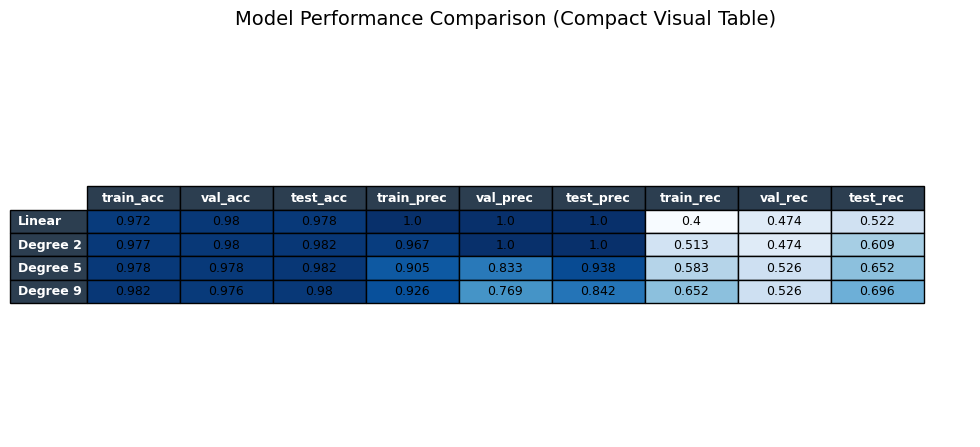

In [37]:
# print the table and show it as figure also 

def build_results_table(results_dict):

    df = pd.DataFrame(results_dict).T

    df = df[
        [
            "train_acc", "val_acc", "test_acc",
            "train_prec", "val_prec", "test_prec",
            "train_rec", "val_rec", "test_rec"
        ]
    ].round(4)

    return df

results = {
    "Linear": {
        "train_acc": train_acc_lin,
        "val_acc": val_acc_lin,
        "test_acc": test_acc_lin,
        "train_prec": train_prec_lin,
        "val_prec": val_prec_lin,
        "test_prec": test_prec_lin,
        "train_rec": train_rec_lin,
        "val_rec": val_rec_lin,
        "test_rec": test_rec_lin,
    },
    "Degree 2": {
        "train_acc": train_acc2,
        "val_acc": val_acc2,
        "test_acc": test_acc2,
        "train_prec": train_prec2,
        "val_prec": val_prec2,
        "test_prec": test_prec2,
        "train_rec": train_rec2,
        "val_rec": val_rec2,
        "test_rec": test_rec2,
    },
    "Degree 5": {
        "train_acc": train_acc5,
        "val_acc": val_acc5,
        "test_acc": test_acc5,
        "train_prec": train_prec5,
        "val_prec": val_prec5,
        "test_prec": test_prec5,
        "train_rec": train_rec5,
        "val_rec": val_rec5,
        "test_rec": test_rec5,
    },
    "Degree 9": {
        "train_acc": train_acc9,
        "val_acc": val_acc9,
        "test_acc": test_acc9,
        "train_prec": train_prec9,
        "val_prec": val_prec9,
        "test_prec": test_prec9,
        "train_rec": train_rec9,
        "val_rec": val_rec9,
        "test_rec": test_rec9,
    }
}

table = build_results_table(results)
print(table)
# === COMPACT COLORED TABLE ===

fig, ax = plt.subplots(figsize=(12, 5))   # smaller width, slightly taller
ax.axis("off")

# Normalize values for color shading
vals = table.values.astype(float)
norm = (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)
cmap = plt.cm.Blues
cell_colors = cmap(norm)

# Build the table
table_visual = plt.table(
    cellText=np.round(vals, 3),
    colLabels=table.columns,
    rowLabels=table.index,
    cellLoc="center",
    cellColours=cell_colors,
    loc="center"
)

# Styling
table_visual.auto_set_font_size(False)
table_visual.set_fontsize(9)        # smaller font
table_visual.scale(0.9, 1.4)        # shrink width, keep height readable

# Style headers
for key, cell in table_visual.get_celld().items():
    r, c = key
    cell.set_edgecolor("black")

    # Header row + row labels
    if r == 0 or c == -1:
        cell.set_facecolor("#2C3E50")
        cell.set_text_props(weight="bold", color="white")

plt.title("Model Performance Comparison (Compact Visual Table)", fontsize=14, pad=20)
plt.show()

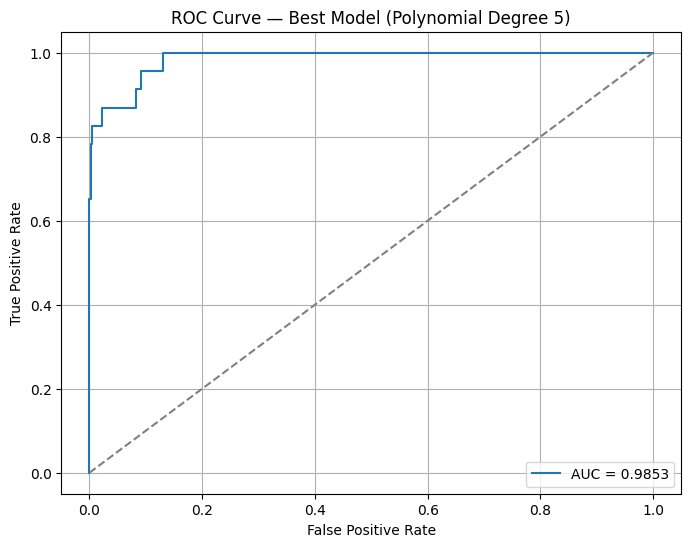

In [38]:
#compute the area under the curve (AUC)
y_scores = model_poly5.predict_proba(X_test_poly5)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc_value = auc(fpr, tpr)
#plot the ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_value:.4f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Best Model (Polynomial Degree 5)")
plt.legend()
plt.grid(True)
plt.show()